# Stacking Optimisé avec Optuna (M-values, sans Data Leakage)

## Protocole rigoureux
1. Chargement des B-values brutes (`c_sample.csv`) + conversion en **M-values**
2. **5-Fold CV** externe pour l'évaluation
3. **À l'intérieur de chaque fold** (train only) :
   - Sélection top-500 CpG par corrélation (train only)
   - Imputation MICE : fit train, transform test
   - StandardScaler : fit train, transform test
   - **Optuna** : optimisation des hyperparamètres via CV interne (train only)
   - Entraînement des modèles de stacking
4. Intervalles de confiance à 95%

## Modèles comparés
0. ElasticNetCV (baseline, sans stacking)
1. Stack Linéaire (ElasticNet + Ridge + Lasso)
2. Stack Arbres (RF + GBR + XGBoost + LightGBM)
3. Stack Mixte (ElasticNet + SVR + RF + XGBoost)
4. Stack Complet (8 base learners)
5. Stack Optuna (hyperparamètres optimisés par Optuna)

In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path
from time import time

from sklearn.linear_model import (
    ElasticNet, ElasticNetCV, Ridge, RidgeCV, Lasso, BayesianRidge
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import (
    RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
)
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import StandardScaler
from scipy import stats
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import seaborn as sns

# === CONSTANTES ===
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_DIR = Path('Data')
TOP_K = 500
N_FOLDS = 5
CHUNK_SIZE = 5000
N_OPTUNA_TRIALS = 40
INNER_CV = 3

MICE_PARAMS = {
    'estimator': BayesianRidge(),
    'n_nearest_features': 100,
    'max_iter': 10,
    'random_state': RANDOM_STATE,
}

BETA_EPS = 1e-6

print('Imports OK')

Imports OK


## Fonctions Utilitaires

In [2]:
def beta_to_m(beta):
    """B-value -> M-value : M = log2(beta / (1 - beta)). Préserve NaN."""
    b = np.clip(beta, BETA_EPS, 1.0 - BETA_EPS)
    b = np.where(np.isnan(beta), np.nan, b)
    return np.log2(b / (1.0 - b))


def select_top_k(X_train, y_train, k):
    """Top-k features par corrélation absolue avec y (NaN-safe, train only)."""
    y_c = y_train - y_train.mean()
    y_den = np.sqrt(np.sum(y_c ** 2))
    col_means = np.nanmean(X_train, axis=0, keepdims=True)
    X_filled = np.where(np.isnan(X_train), col_means, X_train)
    x_c = X_filled - X_filled.mean(axis=0, keepdims=True)
    num = x_c.T @ y_c
    den = np.sqrt(np.sum(x_c ** 2, axis=0)) * y_den
    corrs = np.abs(np.divide(num, den, out=np.zeros_like(num), where=den != 0))
    return np.argsort(corrs)[::-1][:k]


print('Helpers OK')

Helpers OK


## Configurations de Stacking + Optuna

In [3]:
def get_stacking_configs():
    """Configurations de stacking avec hyperparamètres par défaut raisonnables.
    Chaque appel crée des instances fraîches."""
    RS = RANDOM_STATE

    enet  = ('enet',  ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=RS))
    ridge = ('ridge', Ridge(alpha=1.0))
    lasso = ('lasso', Lasso(alpha=0.1, max_iter=10000, random_state=RS))
    svr   = ('svr',   SVR(C=1.0, epsilon=0.1))
    knn   = ('knn',   KNeighborsRegressor(n_neighbors=10, weights='distance'))
    rf    = ('rf',    RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=3, random_state=RS, n_jobs=-1))
    gbr   = ('gbr',   GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=RS))
    xgb   = ('xgb',   XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=RS, n_jobs=-1, verbosity=0))
    lgbm  = ('lgbm',  LGBMRegressor(n_estimators=200, max_depth=5, learning_rate=0.05, random_state=RS, n_jobs=-1, verbosity=-1))

    meta = RidgeCV(alphas=np.logspace(-3, 3, 20))

    return {
        '1. Stack Linéaire': {
            'estimators': [enet, ridge, lasso],
            'final_estimator': RidgeCV(alphas=np.logspace(-3, 3, 20)),
            'cv': 5, 'passthrough': False,
        },
        '2. Stack Arbres': {
            'estimators': [rf, gbr, xgb, lgbm],
            'final_estimator': RidgeCV(alphas=np.logspace(-3, 3, 20)),
            'cv': 5, 'passthrough': False,
        },
        '3. Stack Mixte': {
            'estimators': [enet, svr, rf, xgb],
            'final_estimator': RidgeCV(alphas=np.logspace(-3, 3, 20)),
            'cv': 5, 'passthrough': False,
        },
        '4. Stack Complet': {
            'estimators': [enet, ridge, lasso, svr, knn, rf, gbr, xgb, lgbm],
            'final_estimator': RidgeCV(alphas=np.logspace(-3, 3, 20)),
            'cv': 5, 'passthrough': True,
        },
    }


# ─── Optuna : objectif + reconstruction ───

def optuna_objective(trial, X_tr, y_tr):
    """Objectif Optuna : minimiser MAE via CV interne sur le stacking."""

    # ElasticNet
    enet_alpha = trial.suggest_float('enet_alpha', 1e-4, 10.0, log=True)
    enet_l1    = trial.suggest_float('enet_l1', 0.1, 0.95)
    # Ridge
    ridge_alpha = trial.suggest_float('ridge_alpha', 1e-3, 100.0, log=True)
    # SVR
    svr_C   = trial.suggest_float('svr_C', 0.1, 100.0, log=True)
    svr_eps = trial.suggest_float('svr_eps', 0.01, 1.0, log=True)
    # KNN
    knn_n = trial.suggest_int('knn_n', 3, 25)
    knn_w = trial.suggest_categorical('knn_w', ['uniform', 'distance'])
    # RandomForest
    rf_n     = trial.suggest_int('rf_n', 100, 500, step=50)
    rf_depth = trial.suggest_int('rf_depth', 4, 20)
    rf_leaf  = trial.suggest_int('rf_leaf', 2, 15)
    # XGBoost
    xgb_n     = trial.suggest_int('xgb_n', 100, 600, step=50)
    xgb_depth = trial.suggest_int('xgb_depth', 2, 8)
    xgb_lr    = trial.suggest_float('xgb_lr', 0.01, 0.3, log=True)
    xgb_alpha = trial.suggest_float('xgb_alpha', 0.01, 10.0, log=True)
    xgb_lamb  = trial.suggest_float('xgb_lambda', 0.1, 50.0, log=True)
    # LightGBM
    lgbm_n      = trial.suggest_int('lgbm_n', 100, 600, step=50)
    lgbm_depth  = trial.suggest_int('lgbm_depth', 3, 10)
    lgbm_lr     = trial.suggest_float('lgbm_lr', 0.01, 0.3, log=True)
    lgbm_leaves = trial.suggest_int('lgbm_leaves', 15, 63)
    # Meta-learner
    meta_alpha   = trial.suggest_float('meta_alpha', 1e-3, 100.0, log=True)
    passthrough  = trial.suggest_categorical('passthrough', [True, False])

    estimators = [
        ('enet',  ElasticNet(alpha=enet_alpha, l1_ratio=enet_l1, max_iter=10000, random_state=RANDOM_STATE)),
        ('ridge', Ridge(alpha=ridge_alpha)),
        ('svr',   SVR(C=svr_C, epsilon=svr_eps)),
        ('knn',   KNeighborsRegressor(n_neighbors=knn_n, weights=knn_w)),
        ('rf',    RandomForestRegressor(n_estimators=rf_n, max_depth=rf_depth, min_samples_leaf=rf_leaf, random_state=RANDOM_STATE, n_jobs=-1)),
        ('xgb',   XGBRegressor(n_estimators=xgb_n, max_depth=xgb_depth, learning_rate=xgb_lr, reg_alpha=xgb_alpha, reg_lambda=xgb_lamb, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)),
        ('lgbm',  LGBMRegressor(n_estimators=lgbm_n, max_depth=lgbm_depth, learning_rate=lgbm_lr, num_leaves=lgbm_leaves, random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1)),
    ]

    stack = StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=meta_alpha),
        cv=INNER_CV, passthrough=passthrough, n_jobs=1,
    )

    cv_scores = cross_val_score(
        stack, X_tr, y_tr, cv=INNER_CV,
        scoring='neg_mean_absolute_error', n_jobs=1,
    )
    return -cv_scores.mean()


def build_optuna_stack(params):
    """Reconstruit le StackingRegressor à partir des meilleurs paramètres Optuna."""
    RS = RANDOM_STATE
    estimators = [
        ('enet',  ElasticNet(alpha=params['enet_alpha'], l1_ratio=params['enet_l1'], max_iter=10000, random_state=RS)),
        ('ridge', Ridge(alpha=params['ridge_alpha'])),
        ('svr',   SVR(C=params['svr_C'], epsilon=params['svr_eps'])),
        ('knn',   KNeighborsRegressor(n_neighbors=params['knn_n'], weights=params['knn_w'])),
        ('rf',    RandomForestRegressor(n_estimators=params['rf_n'], max_depth=params['rf_depth'], min_samples_leaf=params['rf_leaf'], random_state=RS, n_jobs=-1)),
        ('xgb',   XGBRegressor(n_estimators=params['xgb_n'], max_depth=params['xgb_depth'], learning_rate=params['xgb_lr'], reg_alpha=params['xgb_alpha'], reg_lambda=params['xgb_lambda'], random_state=RS, n_jobs=-1, verbosity=0)),
        ('lgbm',  LGBMRegressor(n_estimators=params['lgbm_n'], max_depth=params['lgbm_depth'], learning_rate=params['lgbm_lr'], num_leaves=params['lgbm_leaves'], random_state=RS, n_jobs=-1, verbosity=-1)),
    ]
    return StackingRegressor(
        estimators=estimators,
        final_estimator=Ridge(alpha=params['meta_alpha']),
        cv=5, passthrough=params['passthrough'], n_jobs=-1,
    )


print('Stacking configs + Optuna OK')

Stacking configs + Optuna OK


## Chargement des Données (B-values brutes → M-values)

In [4]:
# --- Annotations ---
ind = pd.read_csv(DATA_DIR / 'annot_projet.csv')
ind = ind.dropna(subset=['age', 'Sample_description']).copy()
ind['Sample_description'] = ind['Sample_description'].astype(str)
ind = ind.set_index('Sample_description')

# --- Données brutes ---
data_path = DATA_DIR / 'c_sample.csv'
sample_header = pd.read_csv(data_path, nrows=0)
all_sample_ids = list(sample_header.columns)
common_ids = [s for s in all_sample_ids if s in ind.index]
y = ind.loc[common_ids, 'age'].values.astype(np.float32)
print(f'Échantillons : {len(common_ids)}, âge : {y.mean():.1f} +/- {y.std():.1f}')

# --- Charger tous les CpG + conversion B -> M ---
print('Chargement + conversion M-values...')
t0 = time()
rows = []
for chunk in pd.read_csv(data_path, usecols=common_ids, chunksize=CHUNK_SIZE):
    rows.append(beta_to_m(chunk.to_numpy(dtype=np.float32)))

X_all = np.vstack(rows).T.astype(np.float32)  # (n_samples, n_cpg)
print(f'  {time()-t0:.0f}s | shape={X_all.shape} | NaN={np.isnan(X_all).mean()*100:.2f}%')
print(f'  M-values : [{np.nanmin(X_all):.1f}, {np.nanmax(X_all):.1f}], mean={np.nanmean(X_all):.2f}')

Échantillons : 400, âge : 53.0 +/- 21.2
Chargement + conversion M-values...
  34s | shape=(400, 894006) | NaN=2.67%
  M-values : [-9.6, 9.0], mean=0.98


## 5-Fold CV (sans Data Leakage)

Pour chaque fold :
1. Sélection top-500 CpG (train only, NaN-safe)
2. MICE : fit train, transform test
3. StandardScaler : fit train, transform test
4. Entraînement des 4 stacking à params par défaut
5. **Optuna** : 40 trials avec CV interne (train only) → meilleurs hyperparamètres
6. Entraînement du stack optimisé → évaluation sur test

In [5]:
kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
n_cpg_total = X_all.shape[1]

model_names = [
    '0. ElasticNetCV (baseline)',
    '1. Stack Linéaire',
    '2. Stack Arbres',
    '3. Stack Mixte',
    '4. Stack Complet',
    '5. Stack Optuna',
]
scores = {name: {'mae': [], 'r2': []} for name in model_names}
optuna_best_params = []

print('=' * 70)
print(f'  5-Fold CV | {n_cpg_total} CpG -> top {TOP_K} (M-values)')
print(f'  MICE: BayesianRidge, n_nearest=100 | Optuna: {N_OPTUNA_TRIALS} trials')
print('=' * 70)

for fold_i, (train_idx, test_idx) in enumerate(kf.split(y)):
    print(f'\n{"=" * 60}')
    print(f'  FOLD {fold_i + 1}/{N_FOLDS}  (train={len(train_idx)}, test={len(test_idx)})')
    print(f'{"=" * 60}')

    y_train, y_test = y[train_idx], y[test_idx]
    X_train_all, X_test_all = X_all[train_idx], X_all[test_idx]

    # ── Sélection supervisée INTRA-FOLD (train only) ──
    t0 = time()
    top_idx = select_top_k(X_train_all, y_train, TOP_K)
    X_tr_raw = X_train_all[:, top_idx]
    X_te_raw = X_test_all[:, top_idx]
    print(f'  Feature selection: {TOP_K} CpG ({time()-t0:.1f}s)')

    # ── MICE imputation : fit train, transform test ──
    t0 = time()
    mice = IterativeImputer(**MICE_PARAMS)
    X_tr_imp = mice.fit_transform(X_tr_raw)
    X_te_imp = mice.transform(X_te_raw)
    print(f'  MICE: {time()-t0:.0f}s (NaN train={np.isnan(X_tr_raw).sum()}, test={np.isnan(X_te_raw).sum()})')

    # ── StandardScaler : fit train, transform test ──
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr_imp)
    X_te = scaler.transform(X_te_imp)

    # ── 0. Baseline : ElasticNetCV ──
    enet = ElasticNetCV(cv=5, random_state=RANDOM_STATE, n_jobs=-1)
    enet.fit(X_tr, y_train)
    y_pred = enet.predict(X_te)
    scores['0. ElasticNetCV (baseline)']['mae'].append(mean_absolute_error(y_test, y_pred))
    scores['0. ElasticNetCV (baseline)']['r2'].append(r2_score(y_test, y_pred))
    print(f'  0. Baseline ElasticNetCV  MAE={scores["0. ElasticNetCV (baseline)"]["mae"][-1]:.3f}')

    # ── 1-4. Stacking avec params par défaut ──
    configs = get_stacking_configs()
    for name, cfg in configs.items():
        t0 = time()
        stack = StackingRegressor(
            estimators=cfg['estimators'],
            final_estimator=cfg['final_estimator'],
            cv=cfg['cv'],
            passthrough=cfg['passthrough'],
            n_jobs=-1,
        )
        stack.fit(X_tr, y_train)
        y_pred = stack.predict(X_te)
        mae = mean_absolute_error(y_test, y_pred)
        r2 = r2_score(y_test, y_pred)
        scores[name]['mae'].append(mae)
        scores[name]['r2'].append(r2)
        print(f'  {name}  MAE={mae:.3f}  ({time()-t0:.0f}s)')

    # ── 5. Stack Optuna : optimisation intra-fold ──
    print(f'  Optuna ({N_OPTUNA_TRIALS} trials)...', end=' ', flush=True)
    t0 = time()
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE + fold_i),
    )
    study.optimize(
        lambda trial: optuna_objective(trial, X_tr, y_train),
        n_trials=N_OPTUNA_TRIALS,
        show_progress_bar=False,
    )
    best_p = study.best_params
    optuna_best_params.append(best_p)

    # Entraîner le meilleur stack sur tout le train, évaluer sur test
    best_stack = build_optuna_stack(best_p)
    best_stack.fit(X_tr, y_train)
    y_pred = best_stack.predict(X_te)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    scores['5. Stack Optuna']['mae'].append(mae)
    scores['5. Stack Optuna']['r2'].append(r2)
    print(f'MAE={mae:.3f}  (best inner={study.best_value:.3f}, {time()-t0:.0f}s)')

print('\n' + '=' * 70)
print('CV terminée.')
print('=' * 70)

  5-Fold CV | 894006 CpG -> top 500 (M-values)
  MICE: BayesianRidge, n_nearest=100 | Optuna: 40 trials

  FOLD 1/5  (train=320, test=80)
  Feature selection: 500 CpG (4.8s)
  MICE: 266s (NaN train=21589, test=5062)
  0. Baseline ElasticNetCV  MAE=3.943
  1. Stack Linéaire  MAE=4.355  (2s)
  2. Stack Arbres  MAE=3.690  (10s)
  3. Stack Mixte  MAE=3.204  (6s)
  4. Stack Complet  MAE=4.405  (11s)
  Optuna (40 trials)... MAE=3.695  (best inner=3.434, 821s)

  FOLD 2/5  (train=320, test=80)
  Feature selection: 500 CpG (2.2s)
  MICE: 125s (NaN train=41888, test=10499)
  0. Baseline ElasticNetCV  MAE=3.348
  1. Stack Linéaire  MAE=3.800  (1s)
  2. Stack Arbres  MAE=4.000  (8s)
  3. Stack Mixte  MAE=3.375  (5s)
  4. Stack Complet  MAE=5.850  (9s)
  Optuna (40 trials)... MAE=3.381  (best inner=3.291, 519s)

  FOLD 3/5  (train=320, test=80)
  Feature selection: 500 CpG (3.5s)
  MICE: 143s (NaN train=13581, test=3083)
  0. Baseline ElasticNetCV  MAE=4.224
  1. Stack Linéaire  MAE=4.312  (1s)
  

## Résultats avec Intervalles de Confiance 95%

In [6]:
t_crit = stats.t.ppf(0.975, df=N_FOLDS - 1)

print('\n' + '=' * 85)
print(f'  COMPARAISON STACKING ({N_FOLDS}-fold CV, M-values, IC 95%)')
print(f'  {n_cpg_total} CpG -> top {TOP_K} | MICE (fit train, transform test) | StandardScaler')
print('=' * 85)
print(f"  {'Modèle':<30s} | {'MAE':>6s} {'± CI':>8s} | {'R²':>6s} {'± CI':>8s}")
print(f"  {'-'*30}-+-{'-'*15}-+-{'-'*15}")

summary_rows = []
for name in model_names:
    s = scores[name]
    mae_arr = np.array(s['mae'])
    r2_arr  = np.array(s['r2'])
    mae_ci = t_crit * mae_arr.std(ddof=1) / np.sqrt(N_FOLDS)
    r2_ci  = t_crit * r2_arr.std(ddof=1) / np.sqrt(N_FOLDS)
    print(f"  {name:<30s} | {mae_arr.mean():6.3f} {mae_ci:>7.3f}  | {r2_arr.mean():6.3f} {r2_ci:>7.3f}")
    summary_rows.append({
        'Modèle': name,
        'MAE_mean': mae_arr.mean(), 'MAE_ci95': mae_ci,
        'R2_mean': r2_arr.mean(), 'R2_ci95': r2_ci,
    })

df_summary = pd.DataFrame(summary_rows).sort_values('MAE_mean')
best = df_summary.iloc[0]
print(f"\n  -> Meilleur : {best['Modèle']}")
print(f"     MAE = {best['MAE_mean']:.3f} +/- {best['MAE_ci95']:.3f}  |  R² = {best['R2_mean']:.3f} +/- {best['R2_ci95']:.3f}")

df_summary.to_csv('results/stacking_optuna_results.csv', index=False)
print('\n  Sauvegardé : results/stacking_optuna_results.csv')


  COMPARAISON STACKING (5-fold CV, M-values, IC 95%)
  894006 CpG -> top 500 | MICE (fit train, transform test) | StandardScaler
  Modèle                         |    MAE     ± CI |     R²     ± CI
  -------------------------------+-----------------+----------------
  0. ElasticNetCV (baseline)     |  4.012   0.498  |  0.902   0.062
  1. Stack Linéaire              |  4.226   0.323  |  0.893   0.058
  2. Stack Arbres                |  3.804   0.257  |  0.917   0.039
  3. Stack Mixte                 |  3.492   0.290  |  0.927   0.044
  4. Stack Complet               |  4.991   1.318  |  0.831   0.146
  5. Stack Optuna                |  3.541   0.271  |  0.926   0.042

  -> Meilleur : 3. Stack Mixte
     MAE = 3.492 +/- 0.290  |  R² = 0.927 +/- 0.044

  Sauvegardé : results/stacking_optuna_results.csv


## Visualisation

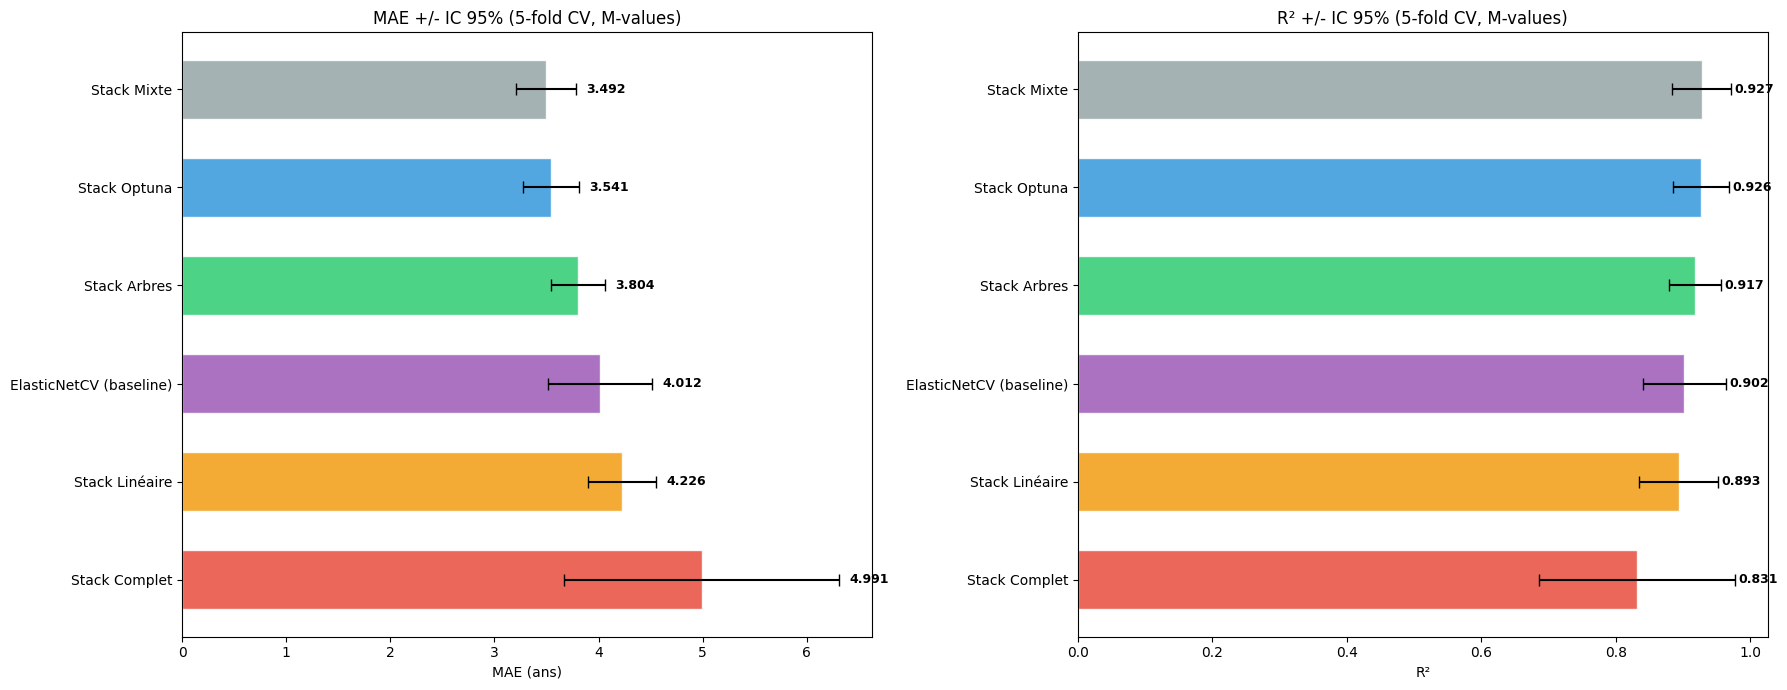

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
models = df_summary['Modèle'].tolist()
colors = ['#95a5a6', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

# --- MAE ---
ax = axes[0]
mae_m = df_summary['MAE_mean'].values
mae_c = df_summary['MAE_ci95'].values
bars = ax.barh(range(len(models)), mae_m, xerr=mae_c, capsize=4,
               color=colors[:len(models)], alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(models)))
ax.set_yticklabels([m.split('. ', 1)[1] for m in models], fontsize=10)
ax.set_xlabel('MAE (ans)')
ax.set_title(f'MAE +/- IC 95% ({N_FOLDS}-fold CV, M-values)')
ax.invert_yaxis()
for i, (m, c) in enumerate(zip(mae_m, mae_c)):
    ax.text(m + c + 0.1, i, f'{m:.3f}', va='center', fontsize=9, fontweight='bold')

# --- R² ---
ax = axes[1]
r2_m = df_summary['R2_mean'].values
r2_c = df_summary['R2_ci95'].values
bars = ax.barh(range(len(models)), r2_m, xerr=r2_c, capsize=4,
               color=colors[:len(models)], alpha=0.85, edgecolor='white', height=0.6)
ax.set_yticks(range(len(models)))
ax.set_yticklabels([m.split('. ', 1)[1] for m in models], fontsize=10)
ax.set_xlabel('R²')
ax.set_title(f'R² +/- IC 95% ({N_FOLDS}-fold CV, M-values)')
ax.invert_yaxis()
for i, (m, c) in enumerate(zip(r2_m, r2_c)):
    ax.text(m + c + 0.005, i, f'{m:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('results/stacking_optuna_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

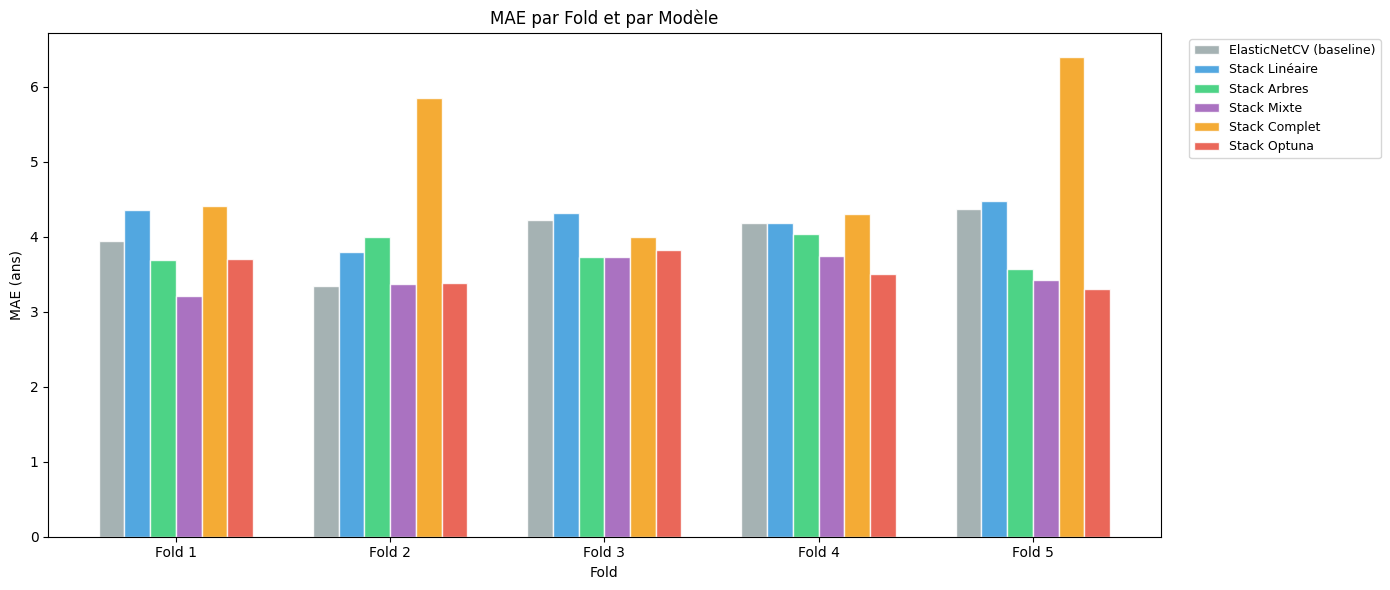

In [ ]:
# --- MAE par fold pour chaque modèle ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(N_FOLDS)
width = 0.12
colors = ['#95a5a6', '#3498db', '#2ecc71', '#9b59b6', '#f39c12', '#e74c3c']

for i, name in enumerate(model_names):
    mae_vals = scores[name]['mae']
    offset = (i - len(model_names) / 2 + 0.5) * width
    bars = ax.bar(x + offset, mae_vals, width, label=name.split('. ', 1)[1],
                  color=colors[i], alpha=0.85, edgecolor='white')

ax.set_xlabel('Fold')
ax.set_ylabel('MAE (ans)')
ax.set_title('MAE par Fold et par Modèle')
ax.set_xticks(x)
ax.set_xticklabels([f'Fold {i+1}' for i in range(N_FOLDS)])
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('results/stacking_optuna_per_fold.png', dpi=150, bbox_inches='tight')
plt.show()


## Meilleurs Hyperparamètres Optuna par Fold

In [9]:
# --- Résumé des hyperparamètres Optuna ---
print('Hyperparamètres Optuna sélectionnés par fold :\n')
key_params = ['enet_alpha', 'enet_l1', 'ridge_alpha', 'svr_C',
              'knn_n', 'rf_n', 'rf_depth', 'xgb_n', 'xgb_depth', 'xgb_lr',
              'lgbm_n', 'lgbm_depth', 'lgbm_lr', 'meta_alpha', 'passthrough']

rows_params = []
for fold_i, bp in enumerate(optuna_best_params):
    row = {'Fold': fold_i + 1}
    for k in key_params:
        v = bp.get(k, '-')
        row[k] = f'{v:.4f}' if isinstance(v, float) else str(v)
    rows_params.append(row)

df_params = pd.DataFrame(rows_params).set_index('Fold')
print(df_params.T.to_string())

# Sauvegarder
df_params.to_csv('results/stacking_optuna_best_params.csv')
print('\nSauvegardé : results/stacking_optuna_best_params.csv')

Hyperparamètres Optuna sélectionnés par fold :

Fold               1        2        3        4        5
enet_alpha    0.1111   1.9335   0.0800   0.0290   1.0387
enet_l1       0.2434   0.3999   0.3692   0.6232   0.7379
ridge_alpha   0.1497   0.3903   0.0024  15.2078   0.0025
svr_C        17.7405   3.1735  25.2494   7.5337   4.6404
knn_n              4       11       19       17        8
rf_n             300      150      150      200      300
rf_depth          10        8        4        9        5
xgb_n            300      200      550      500      250
xgb_depth          4        7        7        8        4
xgb_lr        0.0431   0.0771   0.1974   0.1499   0.1908
lgbm_n           400      150      500      350      200
lgbm_depth         8        6        7        4        9
lgbm_lr       0.2142   0.0502   0.2066   0.0341   0.0311
meta_alpha   25.5440  99.6794   0.7164   0.8066  98.9044
passthrough     True     True    False    False     True

Sauvegardé : results/stacking_optuna_be

## Conclusion

In [10]:
print('=' * 75)
print('  RÉSUMÉ - STACKING OPTIMISÉ (sans data leakage)')
print('=' * 75)
print(f'  Données       : B-values brutes -> M-values, {n_cpg_total} CpG')
print(f'  Sélection     : top {TOP_K} CpG par corrélation (intra-fold, train only)')
print(f'  Imputation    : MICE BayesianRidge n_nearest=100 (fit train, transform test)')
print(f'  Normalisation : StandardScaler (fit train, transform test)')
print(f'  CV            : {N_FOLDS}-fold')
print(f'  Optuna        : {N_OPTUNA_TRIALS} trials, {INNER_CV}-fold CV interne')
print(f'  IC 95%        : t-Student (df={N_FOLDS-1})')
print()
print(f'  Data leakage  : AUCUN')
print(f'    - Feature selection  : train only')
print(f'    - MICE               : fit train, transform test')
print(f'    - StandardScaler     : fit train, transform test')
print(f'    - StackingRegressor  : CV interne sur train pour meta-features')
print(f'    - Optuna             : CV interne sur train uniquement')
print()
print(df_summary[['Modèle', 'MAE_mean', 'MAE_ci95', 'R2_mean', 'R2_ci95']].to_string(index=False))
print(f"\n  Meilleur : {best['Modèle']}")
print(f"  MAE = {best['MAE_mean']:.3f} +/- {best['MAE_ci95']:.3f}")
print(f"  R²  = {best['R2_mean']:.3f} +/- {best['R2_ci95']:.3f}")
print('=' * 75)

  RÉSUMÉ - STACKING OPTIMISÉ (sans data leakage)
  Données       : B-values brutes -> M-values, 894006 CpG
  Sélection     : top 500 CpG par corrélation (intra-fold, train only)
  Imputation    : MICE BayesianRidge n_nearest=100 (fit train, transform test)
  Normalisation : StandardScaler (fit train, transform test)
  CV            : 5-fold
  Optuna        : 40 trials, 3-fold CV interne
  IC 95%        : t-Student (df=4)

  Data leakage  : AUCUN
    - Feature selection  : train only
    - MICE               : fit train, transform test
    - StandardScaler     : fit train, transform test
    - StackingRegressor  : CV interne sur train pour meta-features
    - Optuna             : CV interne sur train uniquement

                    Modèle  MAE_mean  MAE_ci95  R2_mean  R2_ci95
            3. Stack Mixte  3.492419  0.289680 0.927385 0.044212
           5. Stack Optuna  3.541193  0.270775 0.926383 0.041587
           2. Stack Arbres  3.804118  0.256539 0.917348 0.038994
0. ElasticNetCV (ba